In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin_min
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor, kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

In [30]:
df = pd.read_csv('total_consumption_data.csv')
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df['datetime'].dtype, np.number):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

for col in df.columns:
    if col not in ['datetime', 'meter_id']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['meter_id', 'datetime'])
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
df[num_cols] = df.groupby('meter_id')[num_cols].ffill()
df[num_cols] = df.groupby('meter_id')[num_cols].bfill()

# EDA-consistent structural removal: phase-2/3 channels and redundant phase columns.
drop_cols = [
    'aenergy_ph2', 'aenergy_ph3', 'renergy_ph2', 'renergy_ph3',
    'apower_ph2', 'apower_ph3', 'rpower_ph2', 'rpower_ph3',
    'current_ph2', 'current_ph3', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# Remove fully zero and exactly duplicated numeric columns.
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
dup_cols = []
for i, col_i in enumerate(num_cols):
    if col_i in dup_cols:
        continue
    for col_j in num_cols[i + 1:]:
        if col_j in dup_cols:
            continue
        if df[col_i].equals(df[col_j]):
            dup_cols.append(col_j)
if dup_cols:
    df = df.drop(columns=dup_cols)

# Relabel meters as A, B, C ...
meter_ids = sorted(df['meter_id'].dropna().unique().tolist())
meter_map = {mid: chr(65 + i) if i < 26 else f'M{i + 1}' for i, mid in enumerate(meter_ids)}
df['meter_label'] = df['meter_id'].map(meter_map)

df.head(), df.shape, meter_map

(              datetime          meter_id  aenergy  aenergy_ph1  renergy  \
 0  2019-08-27 22:00:05  00124B0018D6F607      4.0      19830.0      0.0   
 6  2019-08-27 22:01:05  00124B0018D6F607      4.0      19834.0      0.0   
 12 2019-08-27 22:02:05  00124B0018D6F607     11.0      19845.0      0.0   
 18 2019-08-27 22:03:05  00124B0018D6F607     22.0      19867.0      0.0   
 24 2019-08-27 22:04:05  00124B0018D6F607     24.0      19891.0      0.0   
 
     renergy_ph1  apower  apower_ph1  rpower_ph1  current_ph1  pfactor  \
 0        4765.0   242.0       242.0       -30.0          1.3      0.9   
 6        4765.0   287.0       287.0       -32.0          1.4      0.9   
 12       4765.0  1354.0      1354.0       -34.0          6.1      1.0   
 18       4765.0  1390.0      1390.0       -36.0          6.2      1.0   
 24       4765.0  1401.0      1401.0       -36.0          6.3      1.0   
 
     pfactor_ph1  voltage_ph1 meter_label  
 0           0.9        223.0           A  
 6      

In [31]:
df_fe = df.copy()

df_fe['apparent_power_ph1'] = df_fe['voltage_ph1'] * df_fe['current_ph1']
df_fe['pf_angle_ph1'] = np.arccos(np.clip(df_fe['pfactor_ph1'], -1, 1))
df_fe['energy_intensity'] = df_fe['aenergy_ph1'] / (df_fe['apparent_power_ph1'] + 1e-6)
df_fe['Q_P_ratio'] = df_fe['rpower_ph1'] / (df_fe['apower_ph1'].abs() + 1e-6)
df_fe['hour'] = df_fe['datetime'].dt.hour
df_fe['dayofweek'] = df_fe['datetime'].dt.dayofweek
df_fe['is_weekend'] = (df_fe['dayofweek'] >= 5).astype(int)
df_fe['is_peak'] = df_fe['hour'].between(8, 20).astype(int)
df_fe['apower_roll3'] = (
    df_fe.groupby('meter_id')['apower_ph1']
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

feature_cols = [
    'aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1', 'apower', 'apower_ph1',
    'rpower_ph1', 'current_ph1', 'pfactor', 'pfactor_ph1', 'voltage_ph1',
    'apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity', 'Q_P_ratio',
    'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3'
]
feature_cols = [c for c in feature_cols if c in df_fe.columns]

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
df_fe[feature_cols] = df_fe[feature_cols].fillna(df_fe[feature_cols].median())

df_fe[feature_cols].describe().T[['mean', 'std', 'min', 'max']].head(20)

,mean,std,min,max
aenergy,7.423823,11.815056,0.000000,3.930000e+02
aenergy_ph1,403405.974469,734831.697033,0.000000,2.137274e+06
renergy,0.393627,0.736261,0.000000,2.100000e+01
renergy_ph1,70654.582943,83265.536261,0.000000,2.480900e+05
apower,391.630920,706.324130,-3858.000000,5.544000e+03
apower_ph1,389.957894,705.699576,-3858.000000,5.544000e+03
rpower_ph1,8.138005,49.277940,-431.000000,2.940000e+02
current_ph1,2.420847,2.787271,0.100000,2.490000e+01
pfactor,0.518663,0.618527,-1.000000,1.000000e+00
pfactor_ph1,0.518663,0.618528,-1.000000,1.000000e+00


Sample used for modeling: 30000
Cumulative explained variance (8 PCs): 0.9591


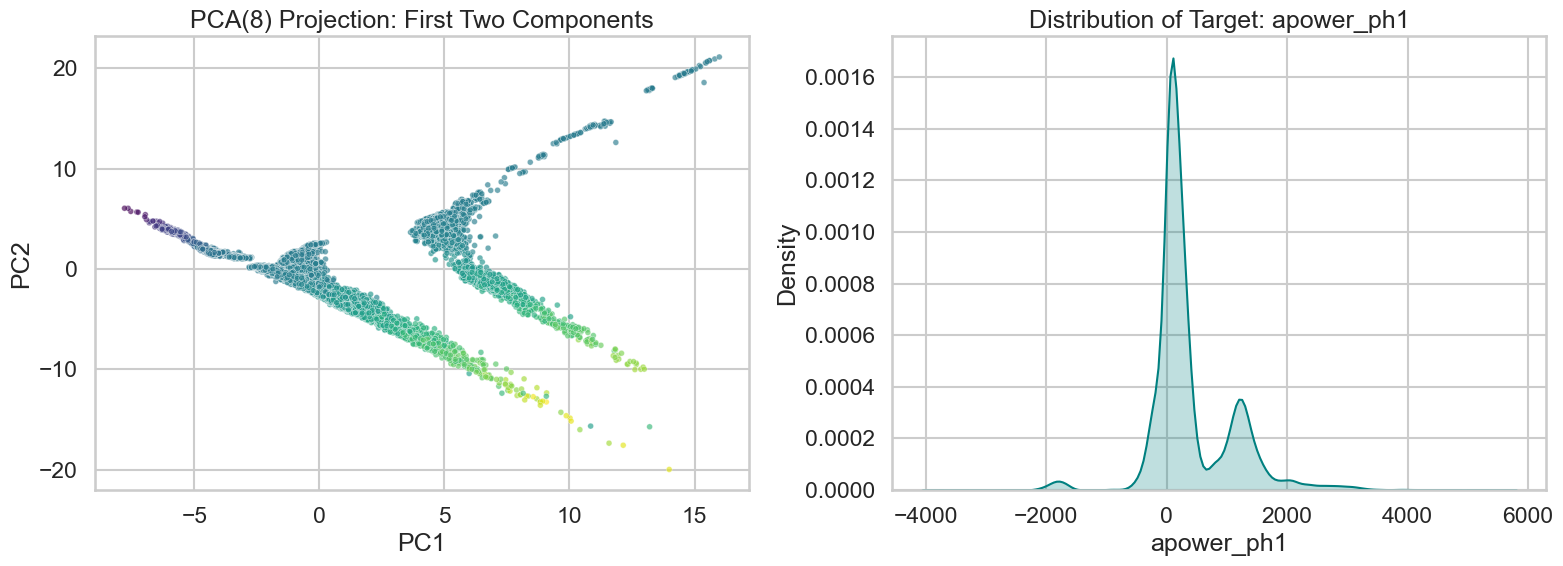

In [32]:
sample_n = min(30000, len(df_fe))
df_model = df_fe.sample(n=sample_n, random_state=42).reset_index(drop=True)

X_raw = df_model[feature_cols].copy()
y = df_model['apower_ph1'].copy()

scalers = {
    'robust': [c for c in feature_cols if c not in ['hour', 'dayofweek', 'is_weekend', 'is_peak', 'voltage_ph1']],
    'minmax': [c for c in ['hour', 'dayofweek', 'is_weekend', 'is_peak'] if c in feature_cols],
    'standard': [c for c in ['voltage_ph1'] if c in feature_cols],
}

X_scaled = X_raw.copy()
if scalers['robust']:
    X_scaled[scalers['robust']] = RobustScaler().fit_transform(X_scaled[scalers['robust']])
if scalers['minmax']:
    X_scaled[scalers['minmax']] = MinMaxScaler().fit_transform(X_scaled[scalers['minmax']])
if scalers['standard']:
    X_scaled[scalers['standard']] = StandardScaler().fit_transform(X_scaled[scalers['standard']])

# Use 8 PCA components for all downstream similarity/modeling steps.
pca_model = PCA(n_components=8, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
X_2d = X_pca[:, :2]
explained_8 = pca_model.explained_variance_ratio_.sum()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, palette='viridis', s=18, alpha=0.65, ax=ax[0], legend=False)
ax[0].set_title('PCA(8) Projection: First Two Components')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

sns.kdeplot(x=y, fill=True, color='teal', ax=ax[1])
ax[1].set_title('Distribution of Target: apower_ph1')
ax[1].set_xlabel('apower_ph1')

plt.tight_layout()
print('Sample used for modeling:', sample_n)
print('Cumulative explained variance (8 PCs):', round(explained_8, 4))

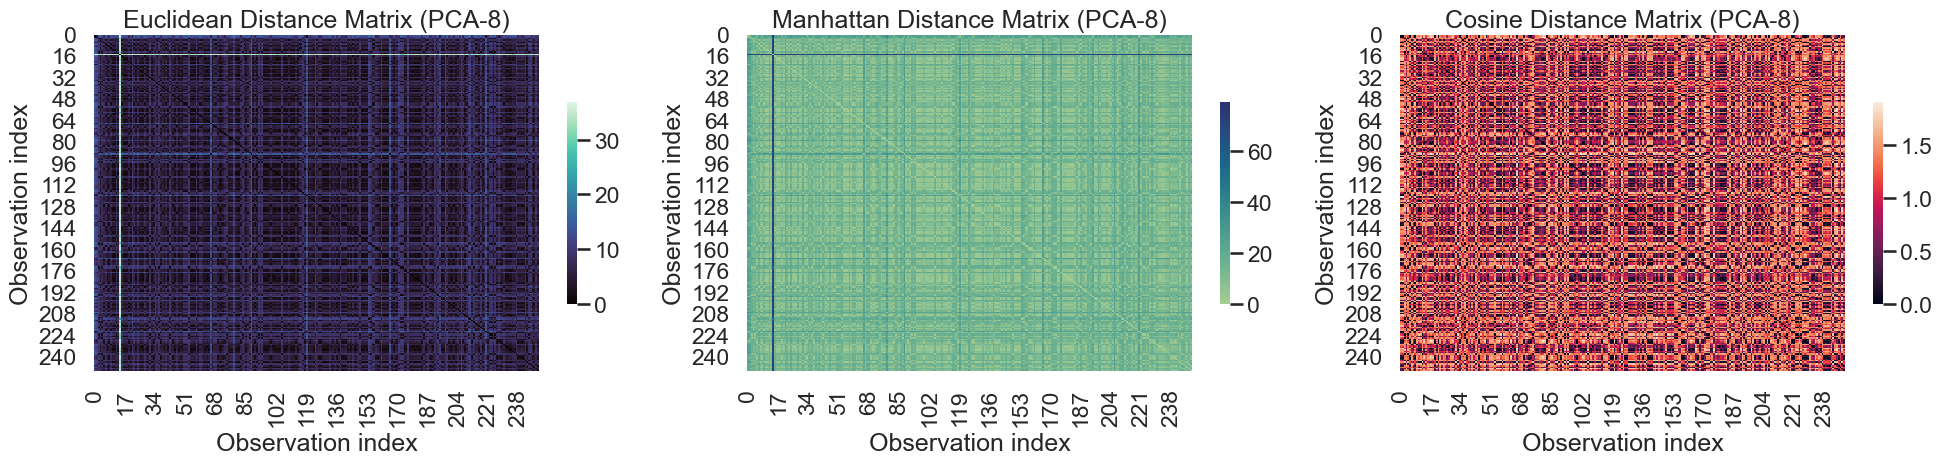

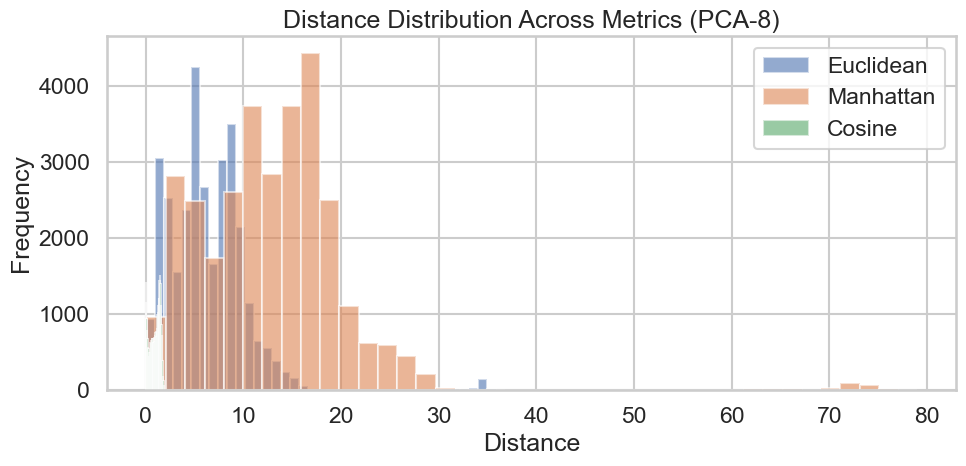

In [33]:
dist_n = min(250, len(X_pca))
X_dist = X_pca[:dist_n]

D_eu = pairwise_distances(X_dist, metric='euclidean')
D_ma = pairwise_distances(X_dist, metric='manhattan')
D_co = pairwise_distances(X_dist, metric='cosine')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(D_eu, cmap='mako', cbar_kws={'shrink': 0.6}, ax=axes[0])
axes[0].set_title('Euclidean Distance Matrix (PCA-8)')

sns.heatmap(D_ma, cmap='crest', cbar_kws={'shrink': 0.6}, ax=axes[1])
axes[1].set_title('Manhattan Distance Matrix (PCA-8)')

sns.heatmap(D_co, cmap='rocket', cbar_kws={'shrink': 0.6}, ax=axes[2])
axes[2].set_title('Cosine Distance Matrix (PCA-8)')

for a in axes:
    a.set_xlabel('Observation index')
    a.set_ylabel('Observation index')

plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(D_eu[np.triu_indices_from(D_eu, 1)], bins=40, alpha=0.6, label='Euclidean')
ax.hist(D_ma[np.triu_indices_from(D_ma, 1)], bins=40, alpha=0.6, label='Manhattan')
ax.hist(D_co[np.triu_indices_from(D_co, 1)], bins=40, alpha=0.6, label='Cosine')
ax.set_title('Distance Distribution Across Metrics (PCA-8)')
ax.set_xlabel('Distance')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()

Anchor 0 | Euclidean neighbor indices: [0, 21887, 11935, 5535, 6806, 6610, 18045, 7763]
Anchor 0 | Cosine neighbor indices:    [0, 21887, 21258, 7390, 11935, 5346, 4477, 29352]
--------------------------------------------------------------------------------
Anchor 10000 | Euclidean neighbor indices: [10000, 19515, 25997, 21253, 20600, 6442, 16086, 22843]
Anchor 10000 | Cosine neighbor indices:    [10000, 19515, 21253, 25997, 20600, 16086, 6442, 412]
--------------------------------------------------------------------------------
Anchor 20000 | Euclidean neighbor indices: [20000, 17334, 10307, 22488, 24271, 15892, 13236, 25527]
Anchor 20000 | Cosine neighbor indices:    [20000, 17334, 10307, 19489, 20657, 22488, 24271, 15892]
--------------------------------------------------------------------------------


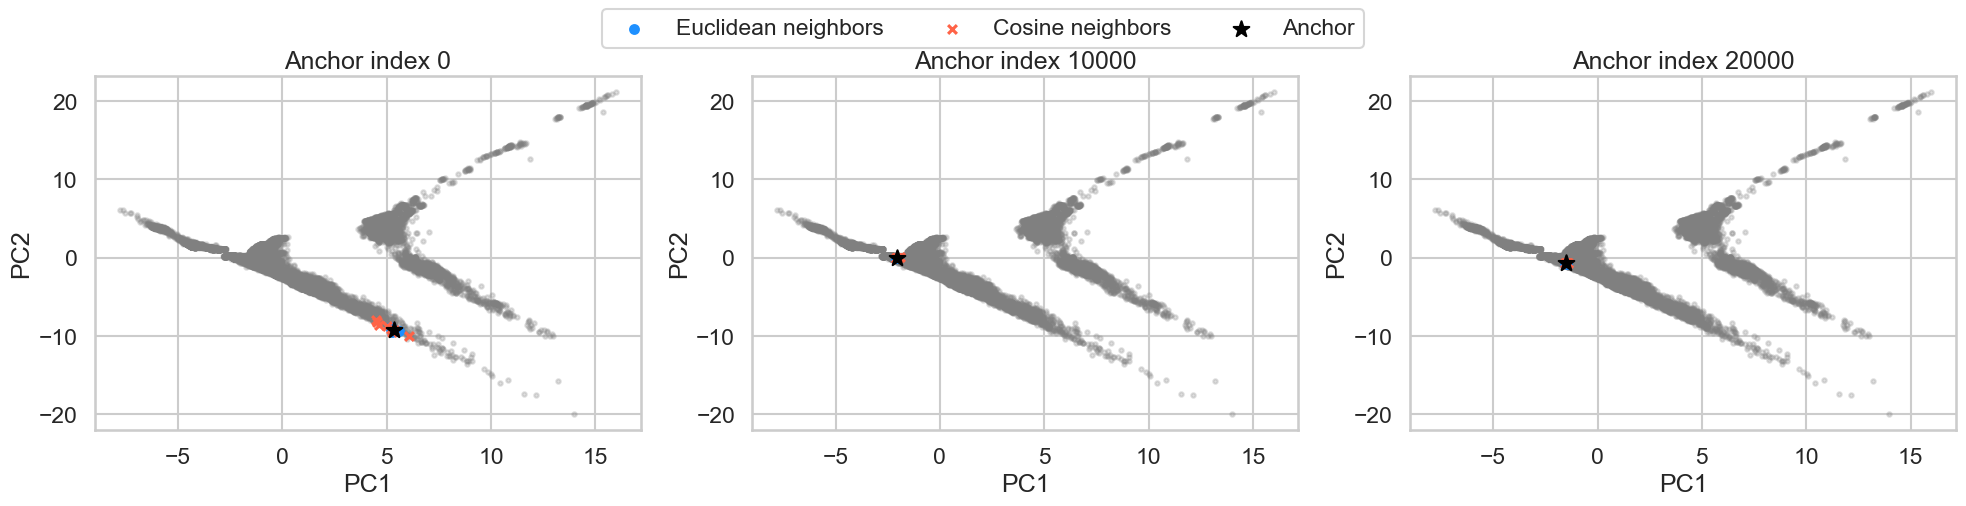

In [34]:
k = 8
nn_eu = NearestNeighbors(n_neighbors=k, metric='euclidean')
nn_co = NearestNeighbors(n_neighbors=k, metric='cosine')
nn_eu.fit(X_pca)
nn_co.fit(X_pca)

anchor_idx = [0, len(X_pca) // 3, 2 * len(X_pca) // 3]
eu_dist, eu_idx = nn_eu.kneighbors(X_pca[anchor_idx])
co_dist, co_idx = nn_co.kneighbors(X_pca[anchor_idx])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, a_idx in enumerate(anchor_idx):
    ax = axes[i]
    ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.25, color='gray')
    ax.scatter(X_2d[eu_idx[i], 0], X_2d[eu_idx[i], 1], s=40, color='dodgerblue', label='Euclidean neighbors')
    ax.scatter(X_2d[co_idx[i], 0], X_2d[co_idx[i], 1], s=40, color='tomato', marker='x', label='Cosine neighbors')
    ax.scatter(X_2d[a_idx, 0], X_2d[a_idx, 1], s=140, color='black', marker='*', label='Anchor')
    ax.set_title(f'Anchor index {a_idx}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()

for i, a_idx in enumerate(anchor_idx):
    print(f'Anchor {a_idx} | Euclidean neighbor indices: {eu_idx[i].tolist()}')
    print(f'Anchor {a_idx} | Cosine neighbor indices:    {co_idx[i].tolist()}')
    print('-' * 80)

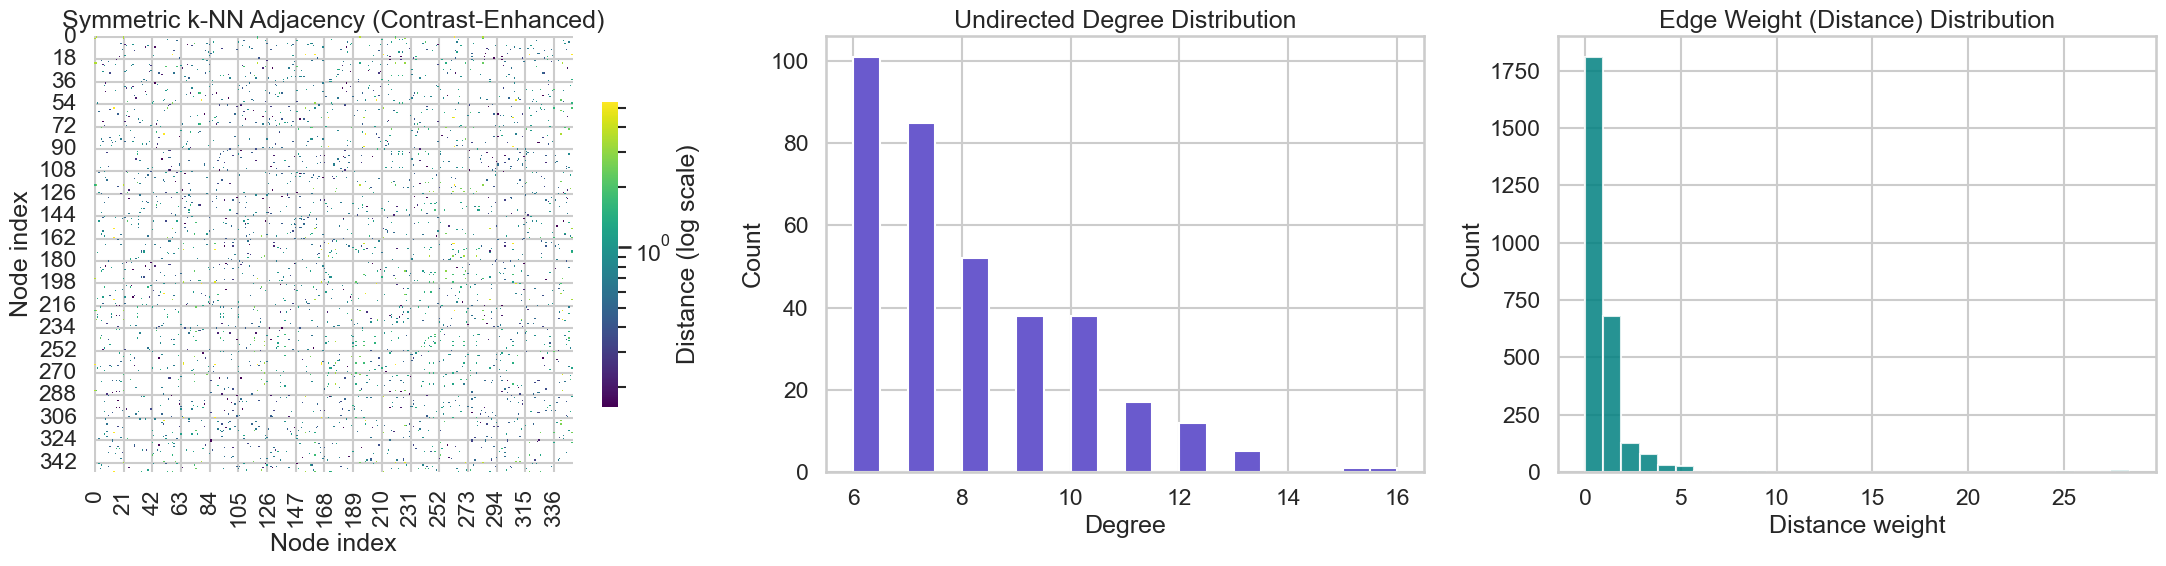

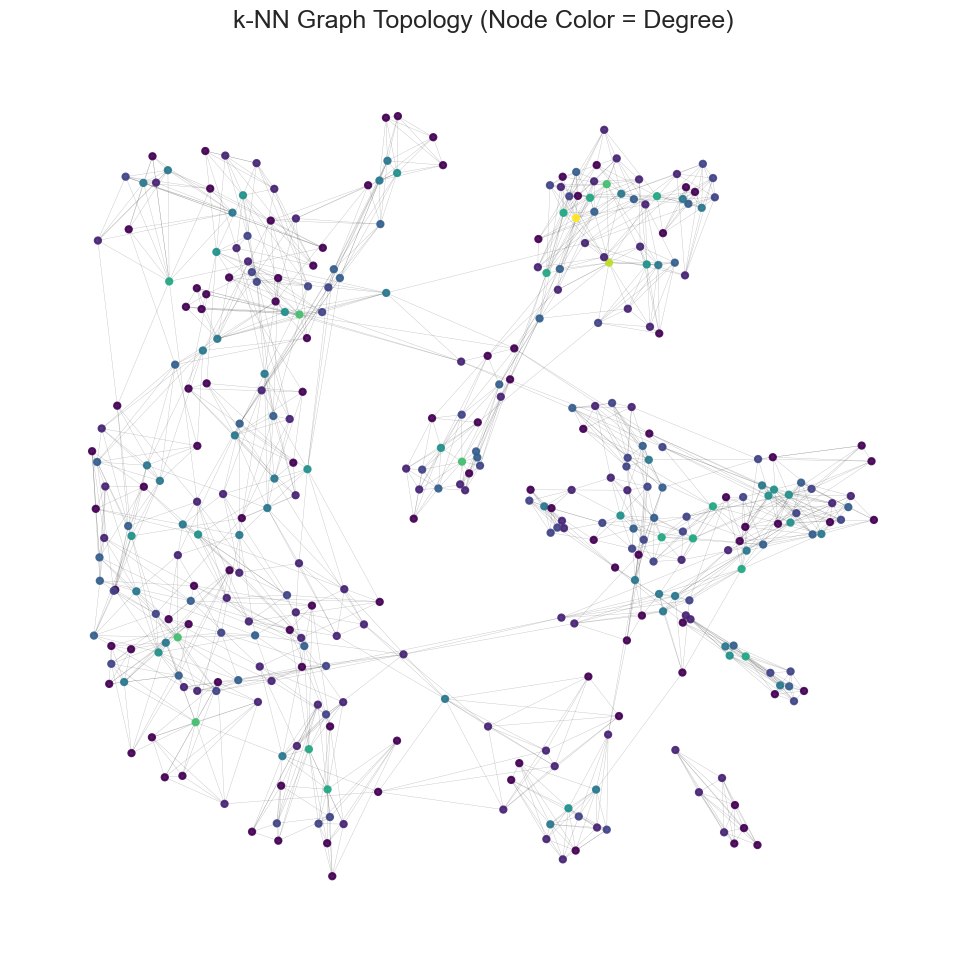

In [35]:
graph_n = min(350, len(X_pca))
A_dir = kneighbors_graph(
    X_pca[:graph_n],
    n_neighbors=6,
    mode='distance',
    metric='euclidean',
    include_self=False,
)

# Symmetrize to inspect structural connectivity beyond fixed out-degree.
A = A_dir.maximum(A_dir.T)
A_dense = A.toarray()
A_plot = np.where(A_dense > 0, A_dense, np.nan)

vmin = max(float(np.nanpercentile(A_plot, 5)), 1e-3)
vmax = float(np.nanpercentile(A_plot, 99))

fig, ax = plt.subplots(1, 3, figsize=(22, 6))
sns.heatmap(
    A_plot,
    cmap='viridis',
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cbar_kws={'shrink': 0.7, 'label': 'Distance (log scale)'},
    ax=ax[0],
)
ax[0].set_title('Symmetric k-NN Adjacency (Contrast-Enhanced)')
ax[0].set_xlabel('Node index')
ax[0].set_ylabel('Node index')

degrees = np.asarray((A > 0).sum(axis=1)).ravel()
ax[1].hist(degrees, bins=20, color='slateblue', edgecolor='white')
ax[1].set_title('Undirected Degree Distribution')
ax[1].set_xlabel('Degree')
ax[1].set_ylabel('Count')

edge_weights = A.data
ax[2].hist(edge_weights, bins=30, color='teal', edgecolor='white', alpha=0.85)
ax[2].set_title('Edge Weight (Distance) Distribution')
ax[2].set_xlabel('Distance weight')
ax[2].set_ylabel('Count')

plt.tight_layout()

try:
    import networkx as nx

    G = nx.from_scipy_sparse_array(A, edge_attribute='weight')
    pos = nx.spring_layout(G, seed=42, k=0.18)
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=20,
        node_color=degrees,
        cmap='viridis',
        alpha=0.9,
    )
    nx.draw_networkx_edges(G, pos, width=0.25, alpha=0.3)
    plt.title('k-NN Graph Topology (Node Color = Degree)')
    plt.axis('off')
    plt.tight_layout()
except Exception as e:
    print('Networkx visualization skipped:', e)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

knn_reg = KNeighborsRegressor(n_neighbors=10, metric='minkowski', p=2, weights='distance')
knn_reg.fit(X_train, y_train)
y_pred_knn = knn_reg.predict(X_test)

metrics_knn = {
    'MAE': mean_absolute_error(y_test, y_pred_knn),
    'RMSE': mean_squared_error(y_test, y_pred_knn, squared=False),
    'R2': r2_score(y_test, y_pred_knn),
}

metrics_knn

{'MAE': 11.005606894291875,
 'RMSE': 35.68795897649649,
 'R2': 0.9973154002084721}

In [37]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=256,
    max_iter=120,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42,
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

metrics_mlp = {
    'MAE': mean_absolute_error(y_test, y_pred_mlp),
    'RMSE': mean_squared_error(y_test, y_pred_mlp, squared=False),
    'R2': r2_score(y_test, y_pred_mlp),
}

metrics_mlp

{'MAE': 15.765365343391439,
 'RMSE': 25.044170979274007,
 'R2': 0.9986779452212998}

In [38]:
# LSTM model on meter-wise temporal sequences.
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    tf.random.set_seed(42)

    seq_df = df_fe.sort_values(['meter_label', 'datetime']).copy()
    seq_features = [c for c in feature_cols if c in seq_df.columns]

    # Scale sequence features and target for stable LSTM training.
    X_seq_scaled = StandardScaler().fit_transform(seq_df[seq_features])
    y_seq = seq_df['apower_ph1'].values.reshape(-1, 1)
    y_seq_scaled = StandardScaler().fit_transform(y_seq).ravel()

    seq_df_features = pd.DataFrame(X_seq_scaled, columns=seq_features, index=seq_df.index)
    seq_df_target = pd.Series(y_seq_scaled, index=seq_df.index)

    lookback = 12
    X_lstm_list, y_lstm_list = [], []

    for meter_name, g in seq_df.groupby('meter_label'):
        idx = g.index
        Xg = seq_df_features.loc[idx].values
        yg = seq_df_target.loc[idx].values

        if len(Xg) <= lookback:
            continue

        for i in range(len(Xg) - lookback):
            X_lstm_list.append(Xg[i:i + lookback])
            y_lstm_list.append(yg[i + lookback])

    X_lstm = np.array(X_lstm_list)
    y_lstm = np.array(y_lstm_list)

    # Keep runtime reasonable.
    max_seq_samples = min(40000, len(X_lstm))
    X_lstm = X_lstm[:max_seq_samples]
    y_lstm = y_lstm[:max_seq_samples]

    split = int(0.8 * len(X_lstm))
    X_lstm_train, X_lstm_test = X_lstm[:split], X_lstm[split:]
    y_lstm_train, y_lstm_test = y_lstm[:split], y_lstm[split:]

    lstm_model = Sequential([
        LSTM(48, input_shape=(X_lstm.shape[1], X_lstm.shape[2]), return_sequences=False),
        Dropout(0.2),
        Dense(24, activation='relu'),
        Dense(1),
    ])

    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_history = lstm_model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_split=0.15,
        epochs=12,
        batch_size=256,
        verbose=0,
    )

    y_pred_lstm_scaled = lstm_model.predict(X_lstm_test, verbose=0).ravel()

    # Inverse transform for interpretable metrics.
    y_scaler = StandardScaler().fit(y_seq)
    y_true_lstm = y_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).ravel()
    y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).ravel()

    metrics_lstm = {
        'MAE': mean_absolute_error(y_true_lstm, y_pred_lstm),
        'RMSE': mean_squared_error(y_true_lstm, y_pred_lstm, squared=False),
        'R2': r2_score(y_true_lstm, y_pred_lstm),
    }

    print('LSTM sequence samples:', len(X_lstm))
    metrics_lstm
except Exception as e:
    metrics_lstm = None
    print('LSTM cell skipped (TensorFlow unavailable or sequence build failed):', e)

LSTM sequence samples: 40000


In [39]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

metrics_rf = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'RMSE': mean_squared_error(y_test, y_pred_rf, squared=False),
    'R2': r2_score(y_test, y_pred_rf),
}

metrics_rf

{'MAE': 10.929844966713057,
 'RMSE': 44.31703325424532,
 'R2': 0.9958602178372785}

,MAE,RMSE,R2
KNN Regressor,11.005607,35.687959,0.997315
MLP Regressor,15.765365,25.044171,0.998678
Random Forest,10.929845,44.317033,0.995860
LSTM,127.558686,274.074288,0.771499


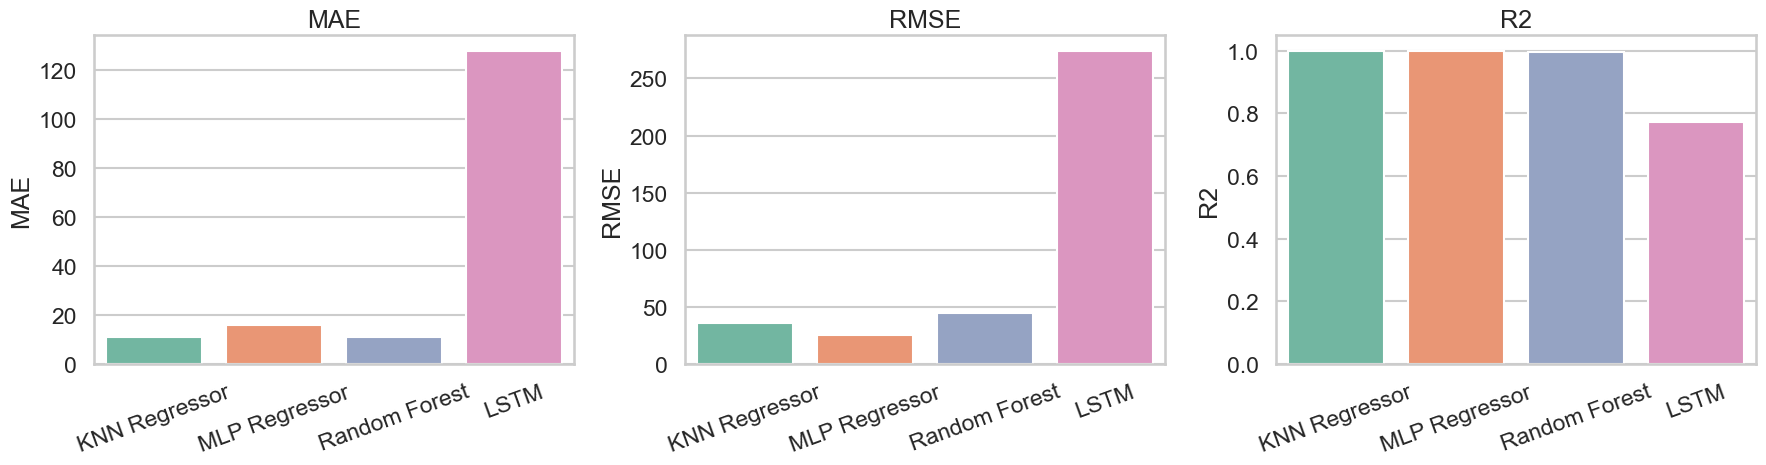

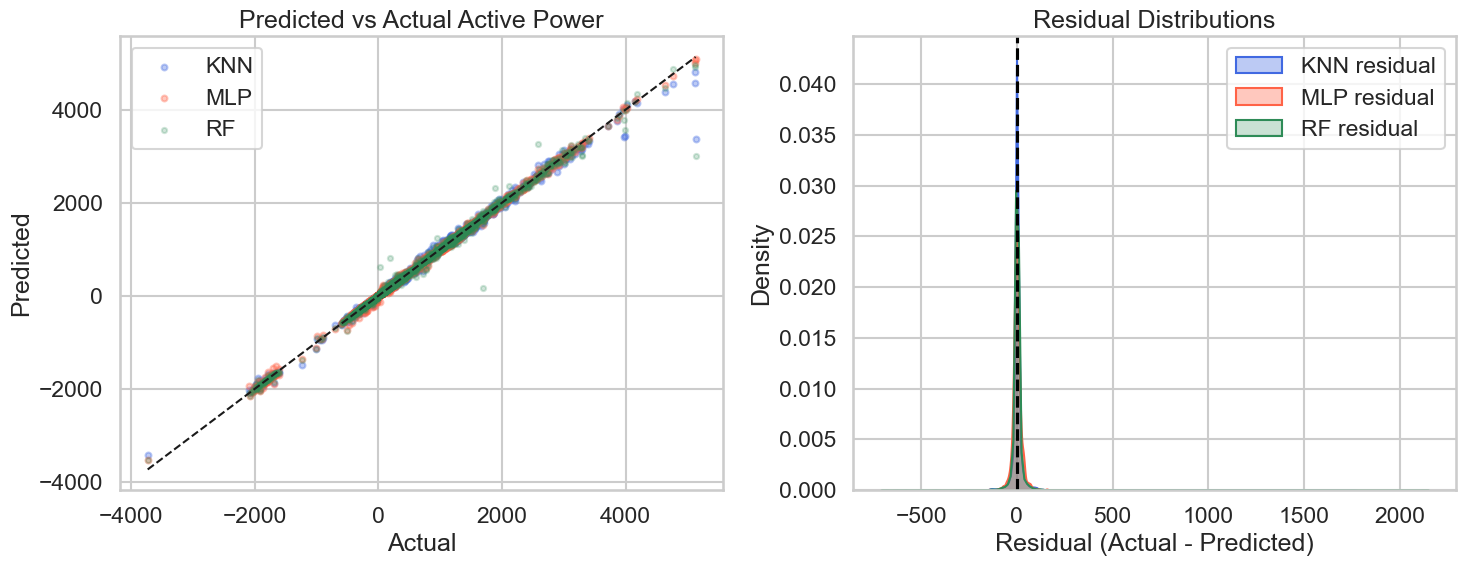

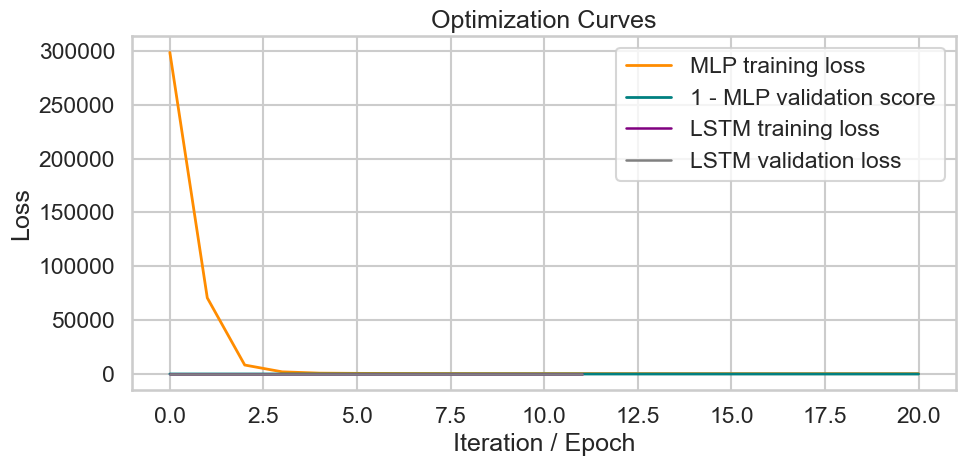

In [40]:
model_rows = [('KNN Regressor', metrics_knn), ('MLP Regressor', metrics_mlp)]

if 'metrics_rf' in globals() and metrics_rf is not None:
    model_rows.append(('Random Forest', metrics_rf))
if 'metrics_lstm' in globals() and metrics_lstm is not None:
    model_rows.append(('LSTM', metrics_lstm))

metrics_df = pd.DataFrame([row[1] for row in model_rows], index=[row[0] for row in model_rows])
display(metrics_df)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, m in enumerate(['MAE', 'RMSE', 'R2']):
    sns.barplot(x=metrics_df.index, y=metrics_df[m], palette='Set2', ax=ax[i])
    ax[i].set_title(m)
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='x', rotation=20)
plt.tight_layout()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].scatter(y_test, y_pred_knn, alpha=0.35, s=18, label='KNN', color='royalblue')
ax[0].scatter(y_test, y_pred_mlp, alpha=0.35, s=18, label='MLP', color='tomato')
if 'y_pred_rf' in globals():
    ax[0].scatter(y_test, y_pred_rf, alpha=0.22, s=14, label='RF', color='seagreen')
mn = min(y_test.min(), y_pred_knn.min(), y_pred_mlp.min())
mx = max(y_test.max(), y_pred_knn.max(), y_pred_mlp.max())
ax[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5)
ax[0].set_title('Predicted vs Actual Active Power')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[0].legend()

res_knn = y_test - y_pred_knn
res_mlp = y_test - y_pred_mlp
sns.kdeplot(res_knn, fill=True, alpha=0.35, label='KNN residual', ax=ax[1], color='royalblue')
sns.kdeplot(res_mlp, fill=True, alpha=0.35, label='MLP residual', ax=ax[1], color='tomato')
if 'y_pred_rf' in globals():
    res_rf = y_test - y_pred_rf
    sns.kdeplot(res_rf, fill=True, alpha=0.25, label='RF residual', ax=ax[1], color='seagreen')
ax[1].axvline(0, color='black', linestyle='--')
ax[1].set_title('Residual Distributions')
ax[1].set_xlabel('Residual (Actual - Predicted)')
ax[1].legend()

plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(mlp.loss_curve_, color='darkorange', lw=2, label='MLP training loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax.plot(1 - np.array(mlp.validation_scores_), color='teal', lw=2, label='1 - MLP validation score')
if 'lstm_history' in globals() and lstm_history is not None:
    ax.plot(lstm_history.history['loss'], color='purple', lw=1.8, label='LSTM training loss')
    if 'val_loss' in lstm_history.history:
        ax.plot(lstm_history.history['val_loss'], color='gray', lw=1.8, label='LSTM validation loss')
ax.set_title('Optimization Curves')
ax.set_xlabel('Iteration / Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()

,meter_label,cosine_distance
0,A,2.220446e-16
1,B,4.525885e-01
2,F,8.889991e-01
3,D,1.226135e+00
4,E,1.264270e+00
5,C,1.596363e+00


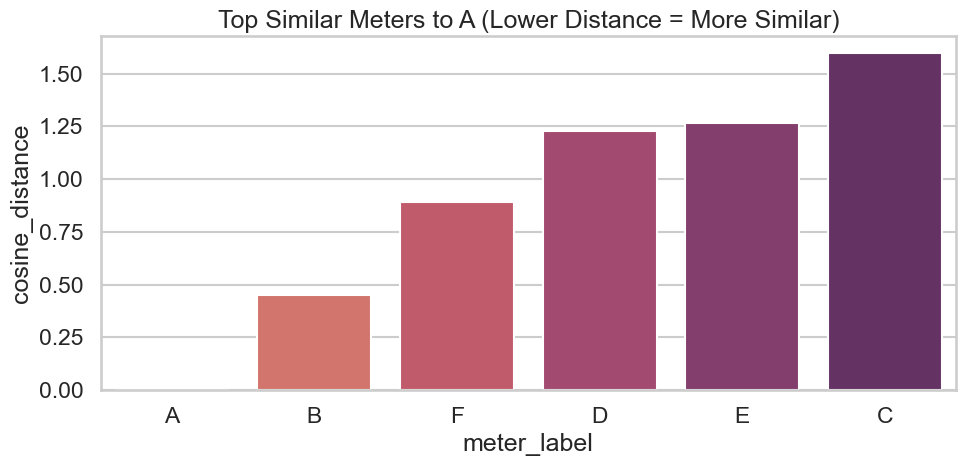

In [41]:
meter_profile = df_fe.groupby('meter_label')[feature_cols].median()
meter_profile = meter_profile.dropna()
meter_profile_scaled = pd.DataFrame(
    RobustScaler().fit_transform(meter_profile),
    index=meter_profile.index,
    columns=meter_profile.columns,
)

query_meter = meter_profile_scaled.index[0]
query_vec = meter_profile_scaled.loc[[query_meter]].values

cosine_dist_all = pairwise_distances(query_vec, meter_profile_scaled.values, metric='cosine').ravel()
rank_idx = np.argsort(cosine_dist_all)[:10]
nearest_meters = meter_profile_scaled.index[rank_idx]
nearest_scores = cosine_dist_all[rank_idx]

sim_df = pd.DataFrame({'meter_label': nearest_meters, 'cosine_distance': nearest_scores})
display(sim_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=sim_df, x='meter_label', y='cosine_distance', palette='flare')
plt.title(f'Top Similar Meters to {query_meter} (Lower Distance = More Similar)')
plt.xticks(rotation=0)
plt.tight_layout()